### dset check 
1. check pair-wise image and truth 
2. check the distribution of the dset. 

In [1]:
import numpy as np
from glob import glob
import rasterio as rio
import geopandas as gpd
import matplotlib as mpl
import cartopy.crs as ccrs
from pyrsimg import imgShow, imsShow
from rasterio.crs import CRS
from notebooks import config 
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
from utils.transform_xy import coor2coor


In [2]:
names_satellite = [path_truth.split('/')[-1][0:2] 
                          for path_truth in config.paths_truth] 
print('Number of scenes:', len(config.paths_scene)) 
print('Satellite:', names_satellite[0])  


Number of scenes: 215
Satellite: l5


#### 1. Check the pair-wise sence and truth images


data/dset/scene/scene_nor/l5/l5_scene_21.tif


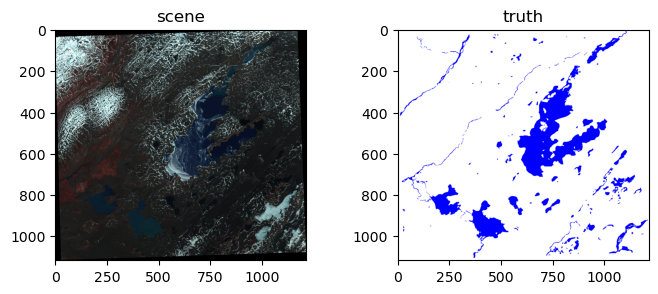

data/dset/scene/scene_nor/l5/l5_scene_22.tif


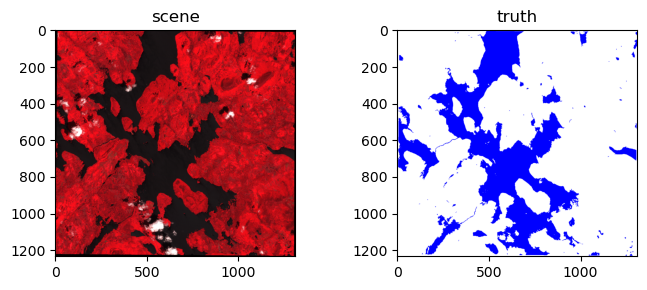

In [3]:
dset = list(zip(config.paths_scene, config.paths_truth))
colors = ['white', 'blue']
cmap = mpl.colors.ListedColormap(colors)

for path_scene, path_truth in dset[20:22]:
        print(path_scene)
        scene_rio = rio.open(path_scene)
        truth_rio = rio.open(path_truth)
        scene_truth_arr = [scene_rio.read().transpose(1,2,0), 
                           truth_rio.read(1)]
        ax = imsShow(img_list=scene_truth_arr,
                img_name_list=['scene', 'truth'], 
                clip_list=[1,0],
                color_bands_list = [(3,2,1), (0,0,0)],
                figsize=(7,3)
                )
        ax[1].imshow(truth_rio.read(1), cmap=cmap);
        plt.tight_layout()
        plt.show()


### 2. show the distribution of the dset.  

In [4]:
dset_gdf = gpd.read_file('data/dset/dset.gpkg')
dset_gdf.head() 


,scene_id,satellite,tra,geometry
0,l5_scene_01,l5,False,POINT (119.57049 -29.09522)
1,l5_scene_02,l5,True,POINT (66.38197 59.88031)
2,l5_scene_03,l5,True,POINT (61.77425 46.04525)
3,l5_scene_04,l5,True,POINT (125.44233 63.95019)
4,l5_scene_05,l5,True,POINT (113.91528 22.58003)


In [5]:
sat_colors = {'l5': 'red', 
              'l7': 'green', 
              'l8': 'blue', 
              'l9': 'orange', 
              'S2': 'purple'} 


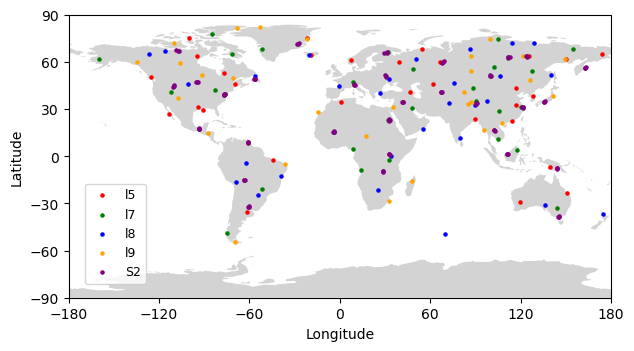

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5), 
                       subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.set_extent([-180, 180, -90, 90])
for sat, color in sat_colors.items():
    dset_gdf[dset_gdf.scene_id.str[0:2] == sat].plot(
                    ax=ax, color=color, marker='o', markersize=5, label=sat)
ax.legend(loc=(0.03,0.05), fontsize=9)
ax.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.tick_params(labelsize=10)
# fig.savefig('figs/dset_distribution.png')


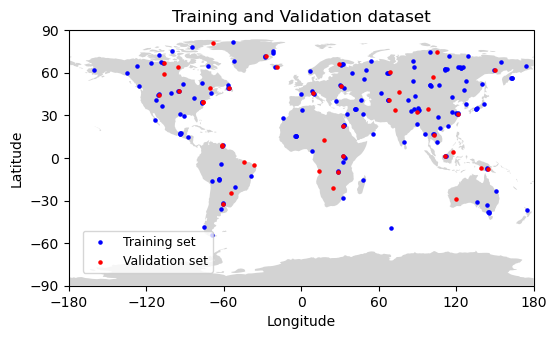

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4), 
                subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.set_extent([-180, 180, -90, 90])
dset_gdf[dset_gdf.tra].plot(
                    ax=ax, 
                    color='blue', 
                    label='Training set',
                    markersize=5)
dset_gdf[~dset_gdf.tra].plot(
                    ax=ax, 
                    color='red', 
                    label='Validation set',
                    markersize=5)
ax.set_title('Training and Validation dataset')
ax.legend(loc=(0.03,0.05), fontsize=9)
ax.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.tick_params(labelsize=10)
# fig.savefig('figs/traset_valset.png', dpi=300)

